# HOMEWORK 3

For this homework you are going to implement the **unsharp masking** filter (USM). It is a technique to improve the sharpness of an image by combining the image with its blurred (unsharp) version. See the Wikipedia [page](https://en.wikipedia.org/wiki/Unsharp_masking) for more details.

### Unsharp Masking (USM)
The USM technique consists of the following steps:
* Load the image you will be working with.
* Create a blurred (unsharp) version of the original image.
* Add the unsharp image (with a certain **weight**) to the original.

To sum it up, the USM performs the following operation:

`sharpened = original + (original − unsharp) × amount`

Even though we provide you an image to work with, you are welcome to use your own images :-)

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

(<Axes: >, <matplotlib.image.AxesImage at 0x72c866ec4e00>)

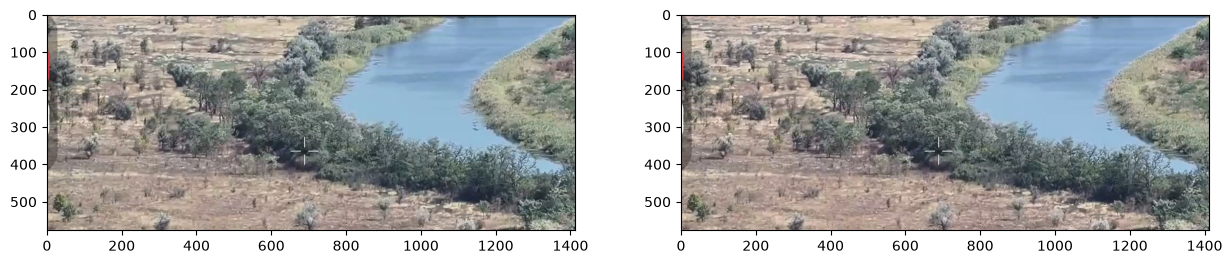

In [46]:
img = cv2.imread('../data/tst.PNG')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

red, green, blue = cv2.split(img)
#max_r = np.max(red)
#max_g = np.max(green)
#max_b = np.max(blue)
#imgX= cv2.merge([red / max_r, green / max_g, blue / max_b])

mean_r = np.mean(red)
mean_g = np.mean(green)
mean_b = np.mean(blue)
mean_max = max(mean_r, mean_g, mean_b)
kr = mean_max / mean_r
kg = mean_max / mean_g
kb = mean_max / mean_b

bal_r = np.clip(red * kr, 0, 255).astype(np.uint8)
bal_g = np.clip(green * kg, 0, 255).astype(np.uint8)
bal_b = np.clip(blue * kb, 0, 255).astype(np.uint8)
imgX = cv2.merge([bal_r, bal_g, bal_b])

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(imgX)


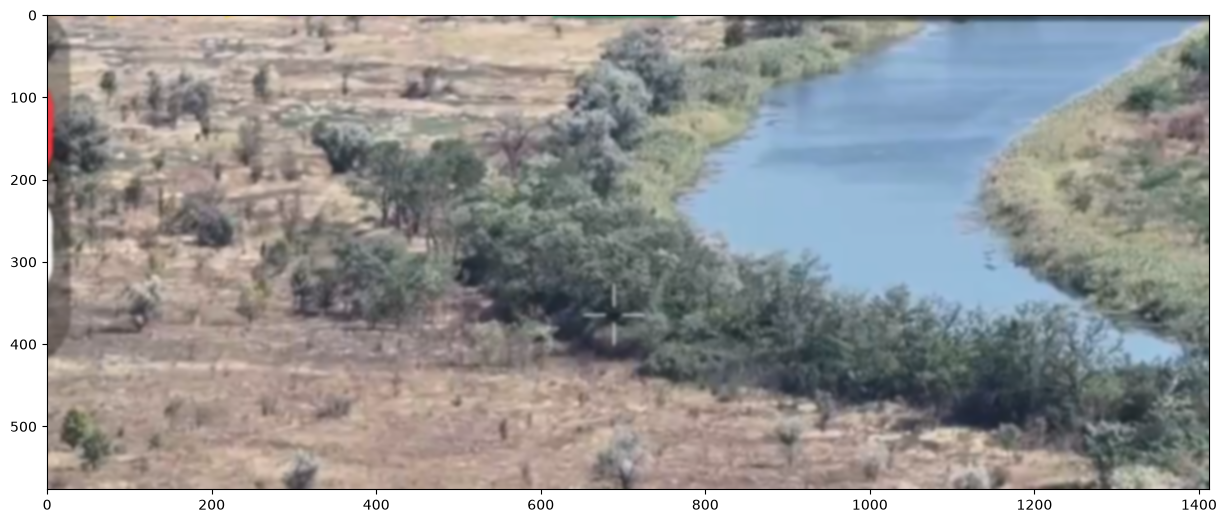

In [47]:
# Create a blurred (unsharp) version of the original image (you can use Gaussian blurring)
krnl = (11,11)
unsharp = cv2.GaussianBlur(imgX, krnl, sigmaX=0)

plt.imshow(unsharp)

In [48]:
# Create the difference image (original − unsharp)
# Note: Remember that you are working with uint8 data types. Any addition or substractions
# might result in overflow or underflow, respectively. You can prevent this by casting the images to float.
diff = imgX.astype(np.float32) - unsharp.astype(np.float32)

(<Axes: >, <matplotlib.image.AxesImage at 0x72c866fcc4d0>)

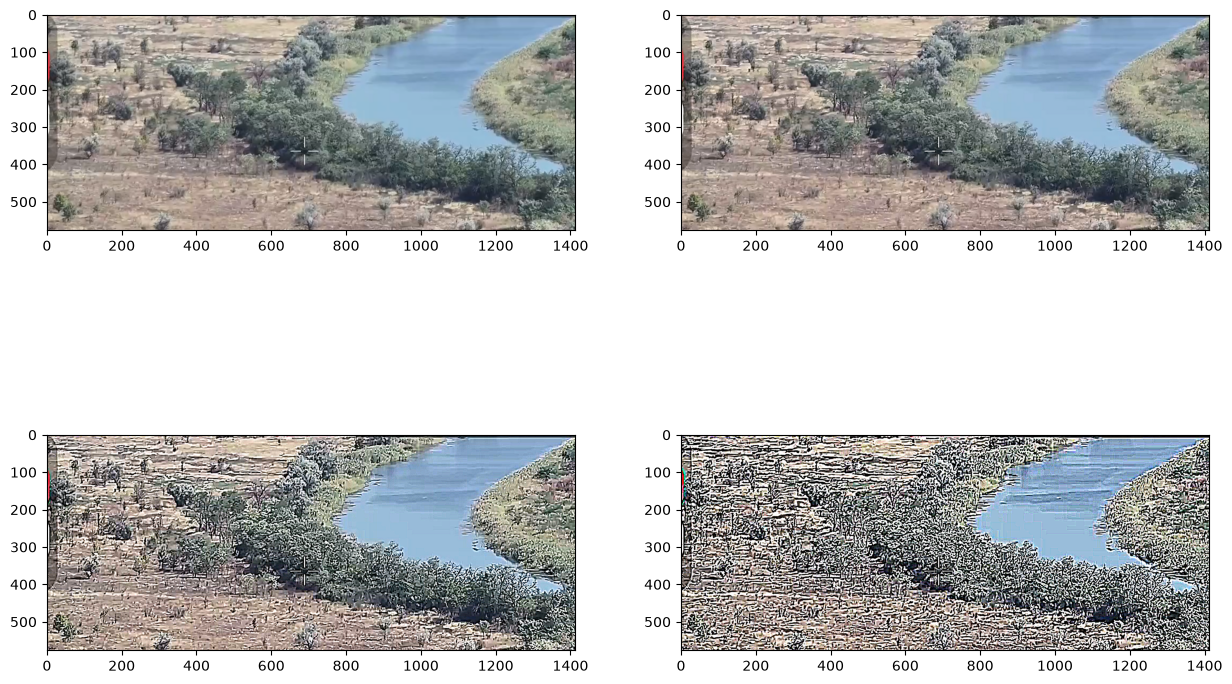

In [49]:
# Apply USM to get the resulting image using `sharpened = original + (original − unsharp) × amount`
# Note: Again, take care of underflows/overflows if necessary.
sharpened1 = imgX.astype(np.float32) + diff * 0.5
sharpened2 = imgX.astype(np.float32) + diff * 5.5
sharpened3 = imgX.astype(np.float32) + diff * 25.5
sharpened1 = np.clip(sharpened1, 0, 255).astype(np.uint8)
sharpened2 = np.clip(sharpened2, 0, 255).astype(np.uint8)
sharpened3 = np.clip(sharpened3, 0, 255).astype(np.uint8)

# Show the original and the sharpened image side by side
plt.subplot(221), plt.imshow(img)
plt.subplot(222), plt.imshow(sharpened1)
plt.subplot(223), plt.imshow(sharpened2)
plt.subplot(224), plt.imshow(sharpened3)

### Questions
* What is a good (reasonable) value for the `amount` parameter?
  I thinhk the reasonable 'amount' value depends on the task and input image: the less information is stored in color and the more in edges, the bigger value is needed
 * What happens if it is too small?
   the too small value has little effect on high frequency component of the image which results in smoother edges
 * What happens if it is too large?
   Too large value results in amplification small and usually unneccessary details and loss of gradiend which can lead to misperception of the image and further mistakes in image processing 